In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
import json

noise2_list=np.array([])
noise_list=np.array([])
noise_indices=np.array([], dtype=int)
NS_ratio_list=np.array([])
ii=0
for i in range(10, 121, 5):
    noise_list=np.append(noise_list, (i/100)*np.sqrt(2.))
    noise2_list=np.append(noise2_list, (i/100)**2*2)
    noise_indices=np.append(noise_indices, ii)
    NS_ratio_list=np.append(NS_ratio_list, (i/100))
    ii+=1

print("noise_list =", noise_list)
print("noise2_list =", noise2_list)
print("noise_indices =", noise_indices)
print("NS_ratio_list =", NS_ratio_list)

noise_list = [0.14142136 0.21213203 0.28284271 0.35355339 0.42426407 0.49497475
 0.56568542 0.6363961  0.70710678 0.77781746 0.84852814 0.91923882
 0.98994949 1.06066017 1.13137085 1.20208153 1.27279221 1.34350288
 1.41421356 1.48492424 1.55563492 1.6263456  1.69705627]
noise2_list = [0.02  0.045 0.08  0.125 0.18  0.245 0.32  0.405 0.5   0.605 0.72  0.845
 0.98  1.125 1.28  1.445 1.62  1.805 2.    2.205 2.42  2.645 2.88 ]
noise_indices = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
NS_ratio_list = [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2 ]


## Initialize parameters

In [2]:

import numpy as np

N_species = 15
N_inp = 6
N_out = 3

N_desc = 50 + 1
Conc_hidden = 1.
Conc_out = 1.
mean = -0.0  # mean of the normal distribution used when cloning (0.02)
sigma = 0.5  # variance used when cloning
sigma_0 = np.sqrt(2.)  # variance of the starting patterns' distribution 
mean_0 = -1.

pp = 0.0  # pp=0 for digital labels
labels_0 = np.array([
    [Conc_out * (10 - pp) / 10., Conc_out * pp / 10., Conc_out * pp / 10.],
    [Conc_out * pp / 10., Conc_out * (10 - pp) / 10., Conc_out * pp / 10.],
    [Conc_out * pp / 10., Conc_out * pp / 10., Conc_out * (10 - pp) / 10.]
])

precision = np.power(10., -6)

noise_scan    = range(10, 121, 5)
drift_scan    = [0, 2, 4, 8]
cocktail_scan = range(1, 49)
noise_scanGD=[0.02,0.245,0.5,0.845,0.98,1.445,2.0,2.42,2.88]


drift_scanGD=['0.0', '0.00001', '0.00005', '0.0001', '0.001', '0.005']

In [3]:

#contrast and mutual information entropy

with open('aggregated_data_EL.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_I_values = data['I']
aggregated_D_values = data['D']

n_patt=48
n_noises=len(noise_scan)
align_I_EL = np.empty((n_patt, n_noises))
align_D_EL = np.empty((n_patt, n_noises))

for i in range(n_patt):
    for j, noise in enumerate(noise_scan):  # Use the actual noise value instead of its index
        average_values = []
        for drift in set(key[0] for key in aggregated_I_values.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_I_values:
                average_values.extend(aggregated_I_values[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_I_EL[i, j] = np.average(average_values)
        else:
            align_I_EL[i, j] = np.nan  # Assign NaN if no values are found

        average_values = []
        for drift in set(key[0] for key in aggregated_D_values.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_D_values:
                average_values.extend(aggregated_D_values[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_D_EL[i, j] = np.average(average_values)
        else:
            align_D_EL[i, j] = np.nan  # Assign NaN if no values are found



noise_scan_GD = [0.02,  0.045, 0.08,  0.125, 0.18,  0.245, 0.32,  0.405, 0.5,   0.605, 0.72,  0.845, \
                 0.98,  1.125, 1.28, 1.445, 1.62, 1.805, 2., 2.205, 2.42, 2.645, 2.88 ]
drift_scan_GD = ['0.0', '0.00001', '0.00005', '0.0001', '0.001', '0.005']

with open('aggregated_data_GD.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_I_values_GD = data['I']
aggregated_D_values_GD = data['D']

n_patt=48
n_noises=len(noise_scan)
align_I_GD = np.empty((n_patt, n_noises))
align_D_GD = np.empty((n_patt, n_noises))

for i in range(n_patt):
    for j, noise in enumerate(noise_scan_GD):  # Use the actual noise value instead of its index
        average_values = []
        for drift in set(key[0] for key in aggregated_I_values_GD.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_I_values_GD:
                average_values.extend(aggregated_I_values_GD[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_I_GD[i, j] = np.average(average_values)
        else:
            align_I_GD[i, j] = np.nan  # Assign NaN if no values are found

        average_values = []
        for drift in set(key[0] for key in aggregated_D_values_GD.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_D_values_GD:
                average_values.extend(aggregated_D_values_GD[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_D_GD[i, j] = np.average(average_values)
        else:
            align_D_GD[i, j] = np.nan  # Assign NaN if no values are found



# hidden concentrations



with open('aggregated_data_HC_values_EL.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_HC_values = data['HC']

n_patt=48
n_noises=len(noise_scan)
align_HC_EL = np.empty((n_patt, n_noises))

for i in range(n_patt):
    for j, noise in enumerate(noise_scan):  # Use the actual noise value instead of its index
        average_values = []
        for drift in set(key[0] for key in aggregated_HC_values.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_HC_values:
                average_values.append(aggregated_HC_values[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_HC_EL[i, j] = np.average(average_values)
        else:
            align_HC_EL[i, j] = np.nan  # Assign NaN if no values are found


noise_scan_GD = [0.02,  0.045, 0.08,  0.125, 0.18,  0.245, 0.32,  0.405, 0.5,   0.605, 0.72,  0.845, \
                 0.98,  1.125, 1.28, 1.445, 1.62, 1.805, 2., 2.205, 2.42, 2.645, 2.88 ]
drift_scan_GD = ['0.0', '0.00001', '0.00005', '0.0001', '0.001', '0.005']

with open('aggregated_data_HC.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_HC_values_GD = data['HC']

n_patt=48
n_noises=len(noise_scan)
align_HC_GD = np.empty((n_patt, n_noises))

for i in range(n_patt):
    for j, noise in enumerate(noise_scan_GD):  # Use the actual noise value instead of its index
        average_values = []
        for drift in set(key[0] for key in aggregated_HC_values_GD.keys()):  # Iterate over all unique drift values
            key = (drift, noise)  # Use the correct key format
            if key in aggregated_HC_values_GD:
                average_values.append(aggregated_HC_values_GD[key][i])  # Append all values for the current drift and noise
        if average_values:  # Check if there are any values to average
            align_HC_GD[i, j] = np.average(average_values)
        else:
            align_HC_GD[i, j] = np.nan  # Assign NaN if no values are found


## Generate figures

## Ranking the cocktails

In [ ]:

import math
import numpy as np
import IPython.display as disp

# Load the data from the .npy file
patterns_0 = np.load(patterns_0_file)

# The data array
data = np.round(patterns_0, 2)

rows = len(data)
cols = len(data[0])
cell_width = 100  # width of each cell in pixels
cell_height = 130 # height of each cell in pixels

# Maximum circle radius for the maximum value in the data.
max_radius = 50
max_value = max(max(row) for row in data)
# Compute a scale factor so that the largest value produces a circle with area = π*max_radius^2.
scale = (math.pi * max_radius**2) / max_value

def radius_for_value(val):
    # Compute circle radius from its area: area = scale * value, r = sqrt(area/π)
    area = scale * val
    return math.sqrt(area / math.pi)

def interpolate_color(col, total_cols, start_color, end_color):
    """
    Linearly interpolate between start_color and end_color.
    Colors are given as (R, G, B) tuples (0-255).
    Returns the interpolated color as a hex string.
    """
    ratio = col / (total_cols - 1) if total_cols > 1 else 0
    r = int(start_color[0] + ratio * (end_color[0] - start_color[0]))
    g = int(start_color[1] + ratio * (end_color[1] - start_color[1]))
    b = int(start_color[2] + ratio * (end_color[2] - start_color[2]))
    return f"#{r:02x}{g:02x}{b:02x}"

# Define start and end colors for columns (green to orange).
violet = (138, 43, 226)     # green in RGB
orange = (255, 165, 0)  # orange in RGB

# Compute overall SVG canvas size.
svg_width = cols * cell_width
svg_height = rows * cell_height

# Start the SVG output.
svg_parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{svg_width}" height="{svg_height}">'
]

# Loop over the data and generate circles and text.
for r in range(rows):
    for c in range(cols):
        value = data[r][c]
        # Determine circle center in the cell.
        cx = c * cell_width + cell_width / 2
        cy = r * cell_height + cell_height / 2
        r_circle = radius_for_value(value)
        # Compute color for the column by interpolating from green to orange.
        fill_color = interpolate_color(c, cols, violet, orange)

        # Create a circle element.
        circle_svg = f'<circle cx="{cx}" cy="{cy}" r="{r_circle:.2f}" fill="{fill_color}" stroke="black" />'
        svg_parts.append(circle_svg)

        # Determine where to place the text:

        if value < 4:
            # Place the text a little above the circle (subtract the radius plus extra padding)
            text_y = cy - r_circle - 5
            text_color = "black"
            text_anchor = "middle"
            dominant_baseline = "baseline"
        else:
            text_y = cy
            if c==5: text_color = "black"
            else: text_color = "white"
            text_anchor = "middle"
            dominant_baseline = "central"

        text_svg = f'<text x="{cx}" y="{text_y}" font-size="15" text-anchor="{text_anchor}" dominant-baseline="{dominant_baseline}" fill="{text_color}" font-weight="bold" >{value}</text>'
        svg_parts.append(text_svg)

svg_parts.append('</svg>')
svg_output = "\n".join(svg_parts)

# Save the SVG to a file (optional)
with open("visualization.svg", "w") as f:
    f.write(svg_output)

# Display the SVG preview (works in Jupyter Notebook)
disp.display(disp.SVG(svg_output))

[32  0 44 16 22 21 38 19  1  7 14  6 39 12  5 31 45 24 40 43 29 41 25 17
 13  4 47 23 30 11  2 37  9 20 42  8 46 33 34 26 10 28 27 36 15  3 35 18]


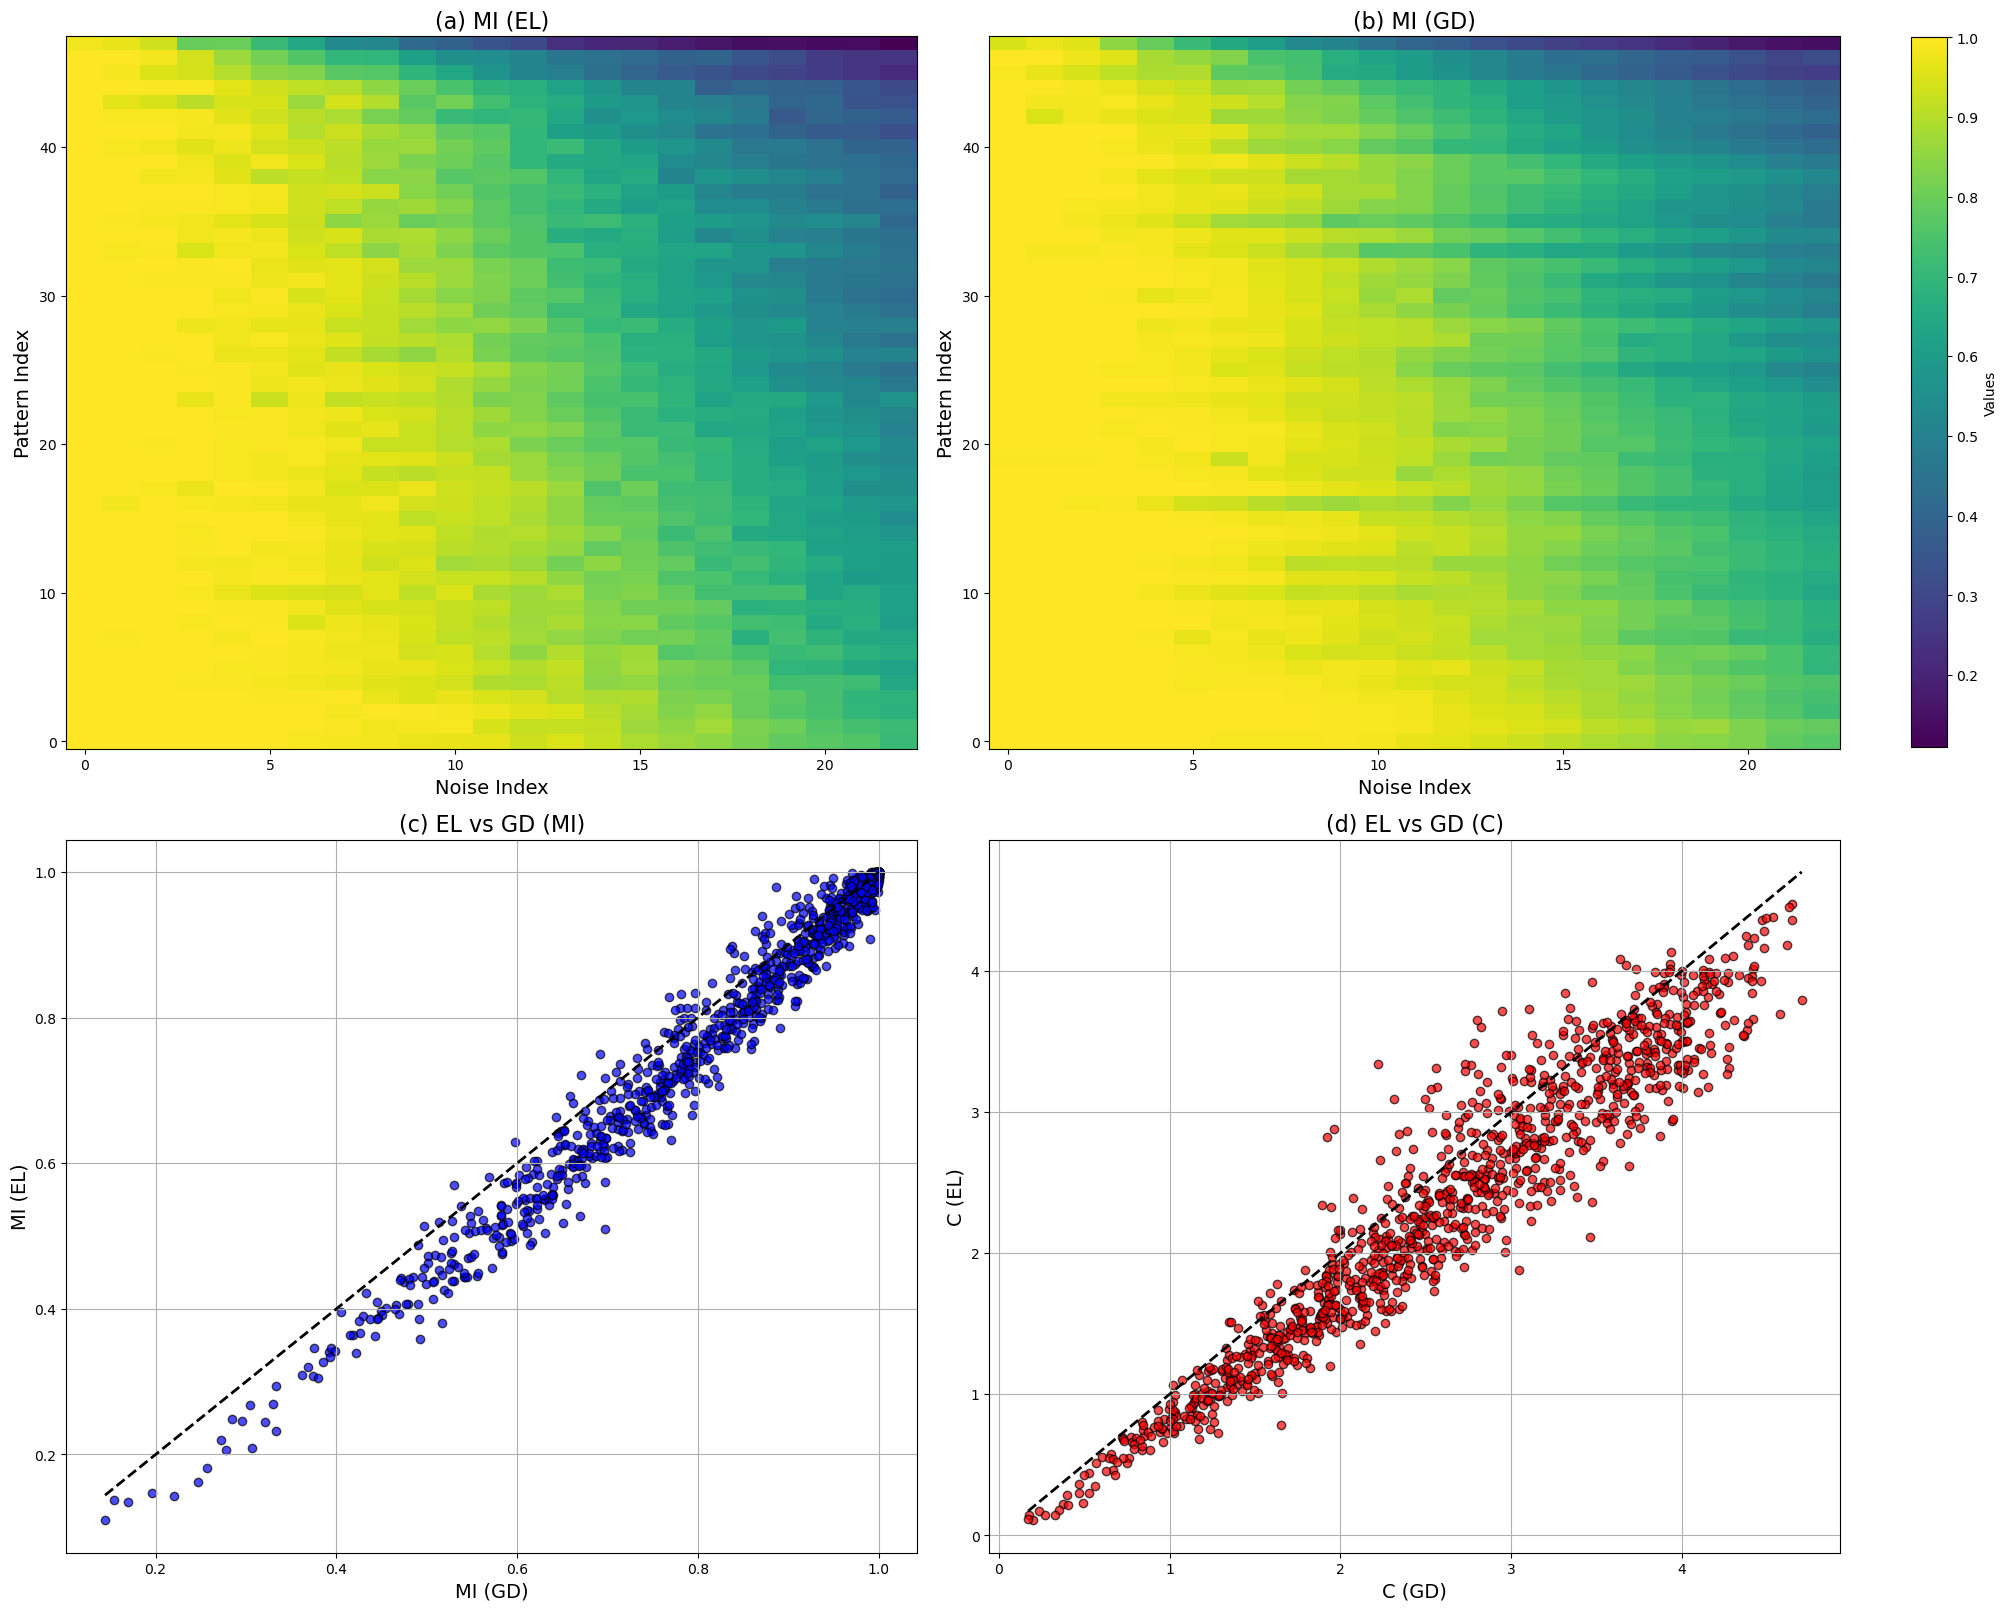

In [14]:
vv=np.sum(align_I_EL,axis=1)
order = np.argsort(-vv)  # Sort indices in descending order
print(order)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 16), constrained_layout=True)

# Panel (a): Plot align_I_EL
im1 = axes[0, 0].imshow(align_I_EL[order[:], :], aspect='auto', cmap='viridis', origin='lower', vmin=align_I_EL.min(), vmax=align_I_EL.max())
axes[0, 0].set_title('(a) MI (EL)', fontsize=16)
axes[0, 0].set_xlabel('Noise Index', fontsize=14)
axes[0, 0].set_ylabel('Pattern Index', fontsize=14)

# Panel (b): Plot align_I_GD
im2 = axes[0, 1].imshow(align_I_GD[order[:], :], aspect='auto', cmap='viridis', origin='lower', vmin=align_I_EL.min(), vmax=align_I_EL.max())
axes[0, 1].set_title('(b) MI (GD)', fontsize=16)
axes[0, 1].set_xlabel('Noise Index', fontsize=14)
axes[0, 1].set_ylabel('Pattern Index', fontsize=14)

# Add a shared colorbar for the first two panels
cbar = fig.colorbar(im1, ax=axes[0, :], orientation='vertical', fraction=0.02, pad=0.04, label='Values')

# Panel (c): Scatter plot for EL vs GD (MI)
axes[1, 0].scatter(align_I_GD.flatten(), align_I_EL.flatten(), alpha=0.7, c='blue', edgecolors='k')
axes[1, 0].plot([align_I_GD.min(), align_I_GD.max()], [align_I_GD.min(), align_I_GD.max()], color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('MI (GD)', fontsize=14)
axes[1, 0].set_ylabel('MI (EL)', fontsize=14)
axes[1, 0].set_title('(c) EL vs GD (MI)', fontsize=16)
axes[1, 0].grid(True)

# Panel (d): Scatter plot for EL vs GD (C)
axes[1, 1].scatter(align_D_GD.flatten(), align_D_EL.flatten(), alpha=0.7, c='red', edgecolors='k')
axes[1, 1].plot([align_D_GD.min(), align_D_GD.max()], [align_D_GD.min(), align_D_GD.max()], color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('C (GD)', fontsize=14)
axes[1, 1].set_ylabel('C (EL)', fontsize=14)
axes[1, 1].set_title('(d) EL vs GD (C)', fontsize=16)
axes[1, 1].grid(True)

plt.show()


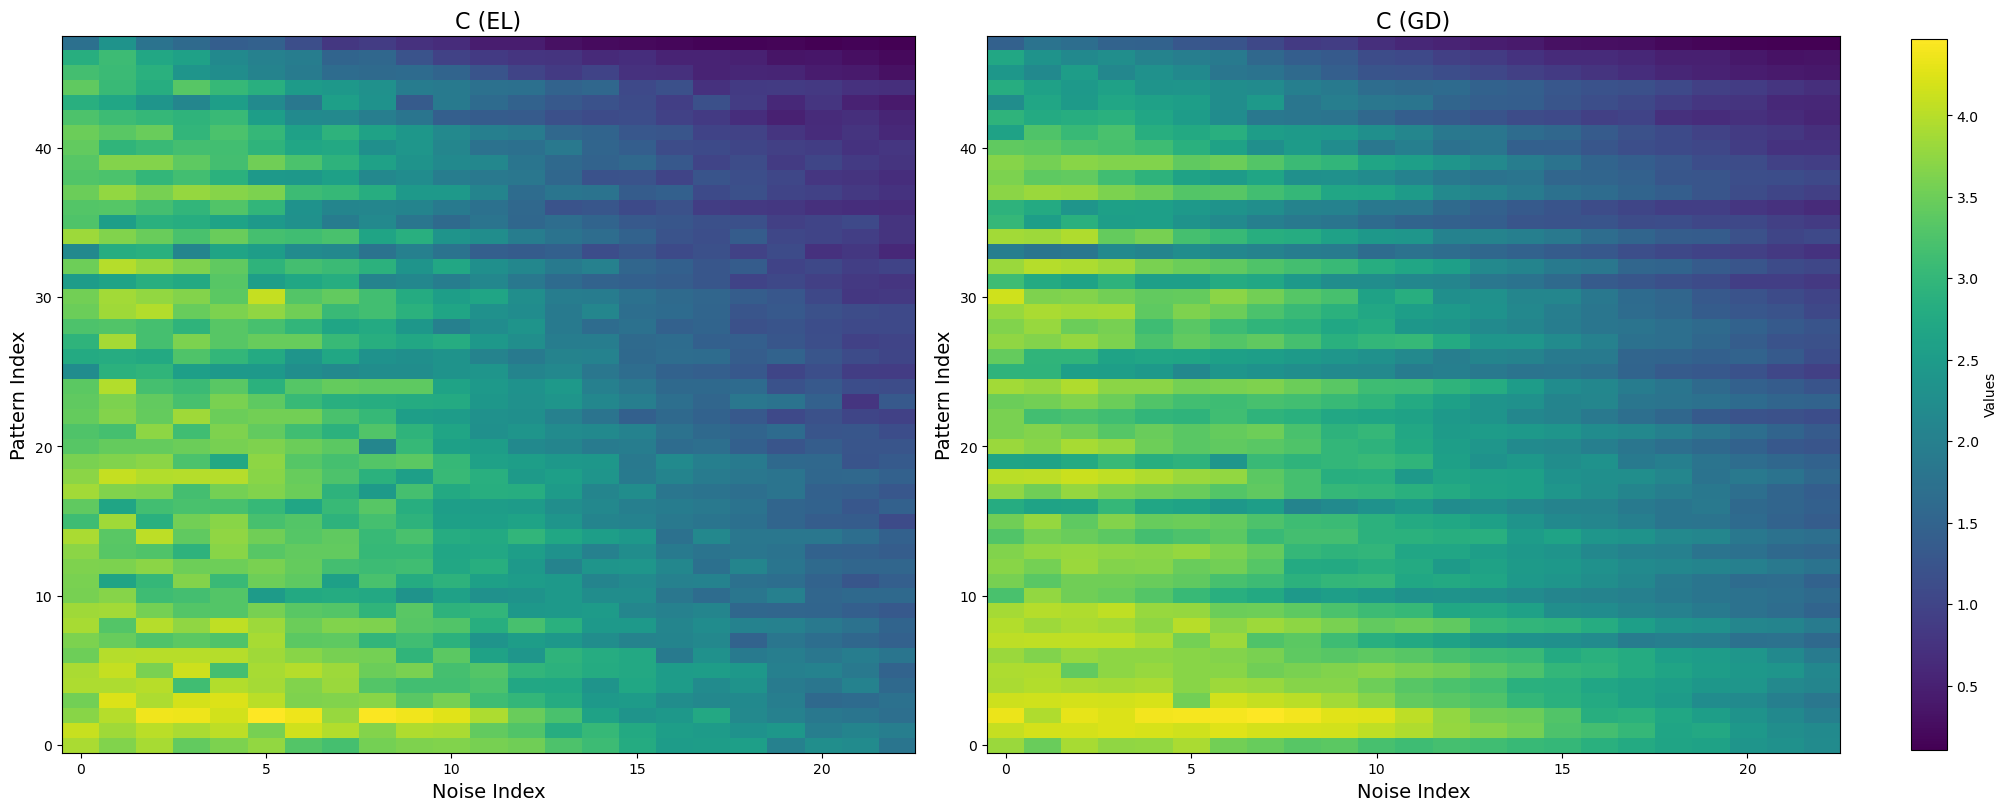

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Plot align_I_EL
im1 = axes[0].imshow(align_D_EL[order[:],:], aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('C (EL)', fontsize=16)
axes[0].set_xlabel('Noise Index', fontsize=14)
axes[0].set_ylabel('Pattern Index', fontsize=14)

# Plot align_I_GD
im2 = axes[1].imshow(align_D_GD[order[:],:], aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('C (GD)', fontsize=16)
axes[1].set_xlabel('Noise Index', fontsize=14)
axes[1].set_ylabel('Pattern Index', fontsize=14)

# Add a common colorbar
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Values')

plt.show()

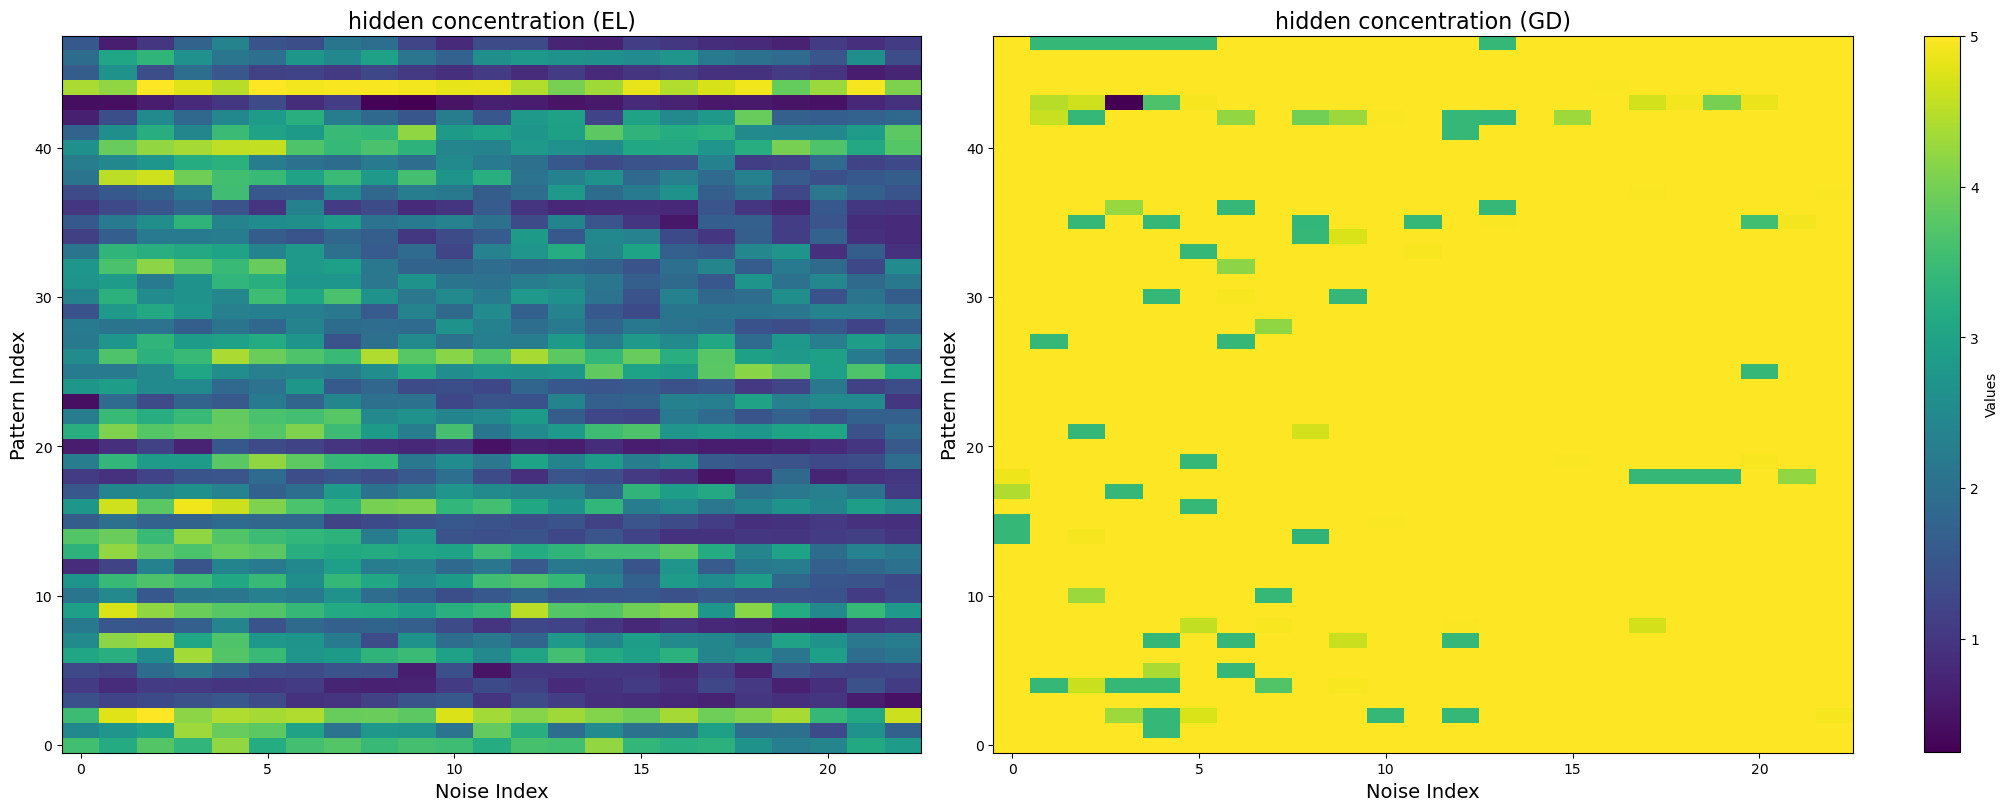

In [7]:

#hidden concentrations

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Plot align_HC_EL
im1 = axes[0].imshow(align_HC_EL, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('hidden concentration (EL)', fontsize=16)
axes[0].set_xlabel('Noise Index', fontsize=14)
axes[0].set_ylabel('Pattern Index', fontsize=14)

# Plot align_HC_GD
im2 = axes[1].imshow(align_HC_GD, aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('hidden concentration (GD)', fontsize=16)
axes[1].set_xlabel('Noise Index', fontsize=14)
axes[1].set_ylabel('Pattern Index', fontsize=14)

# Add a common colorbar
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Values')

plt.show()

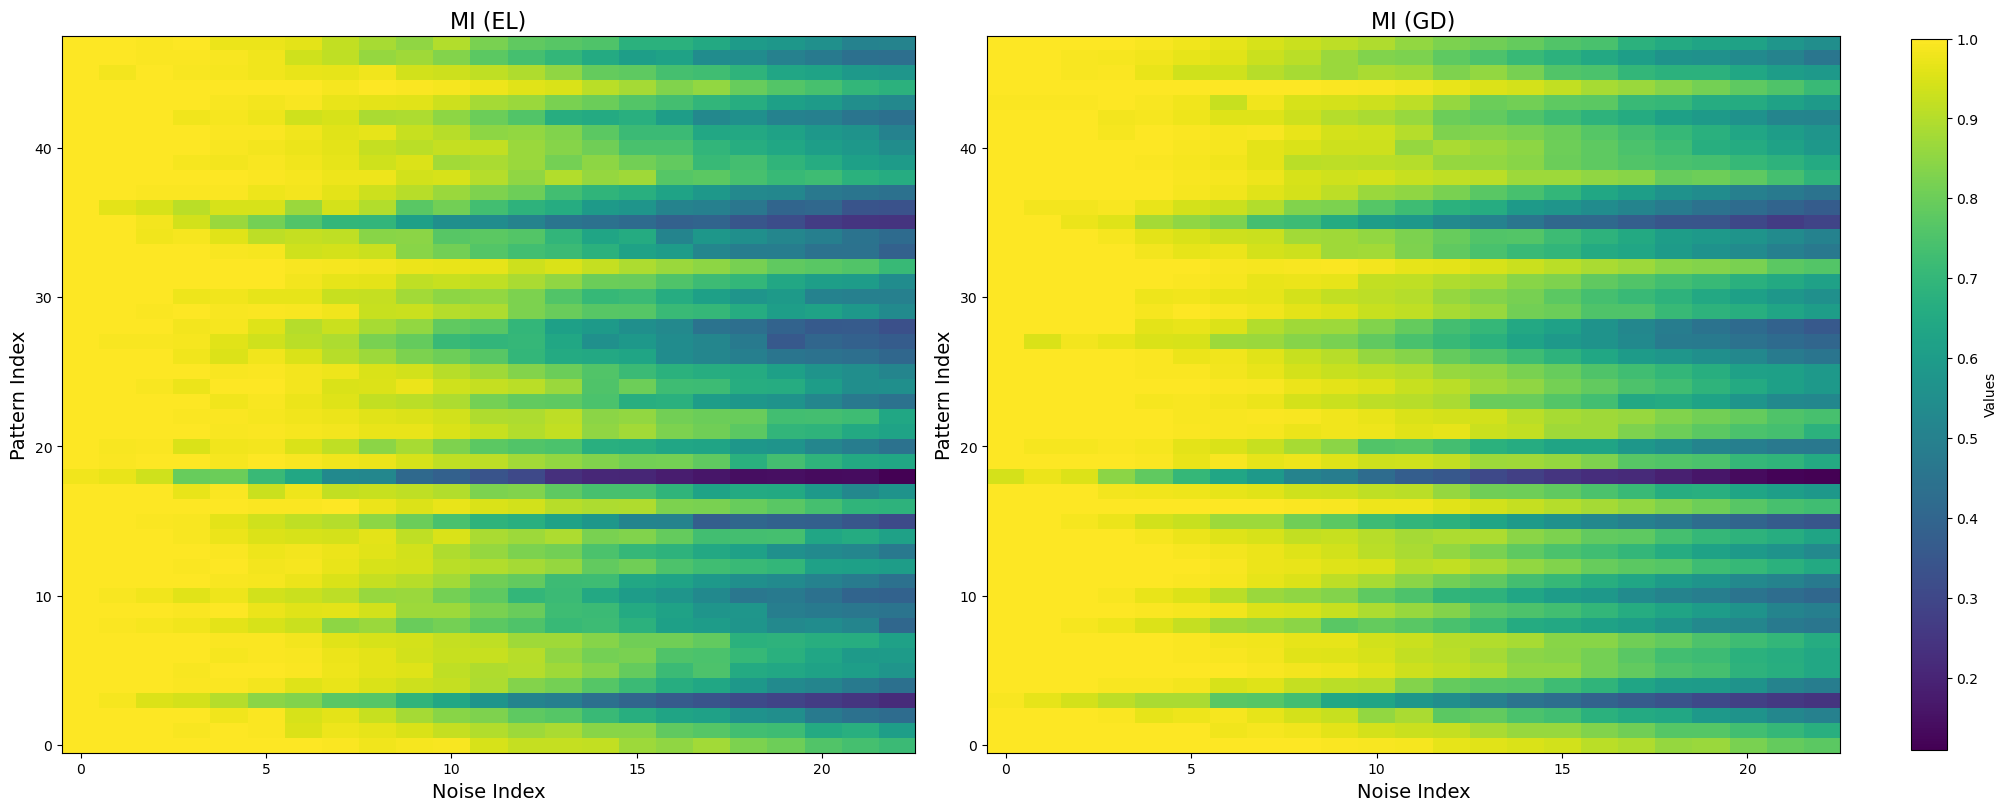

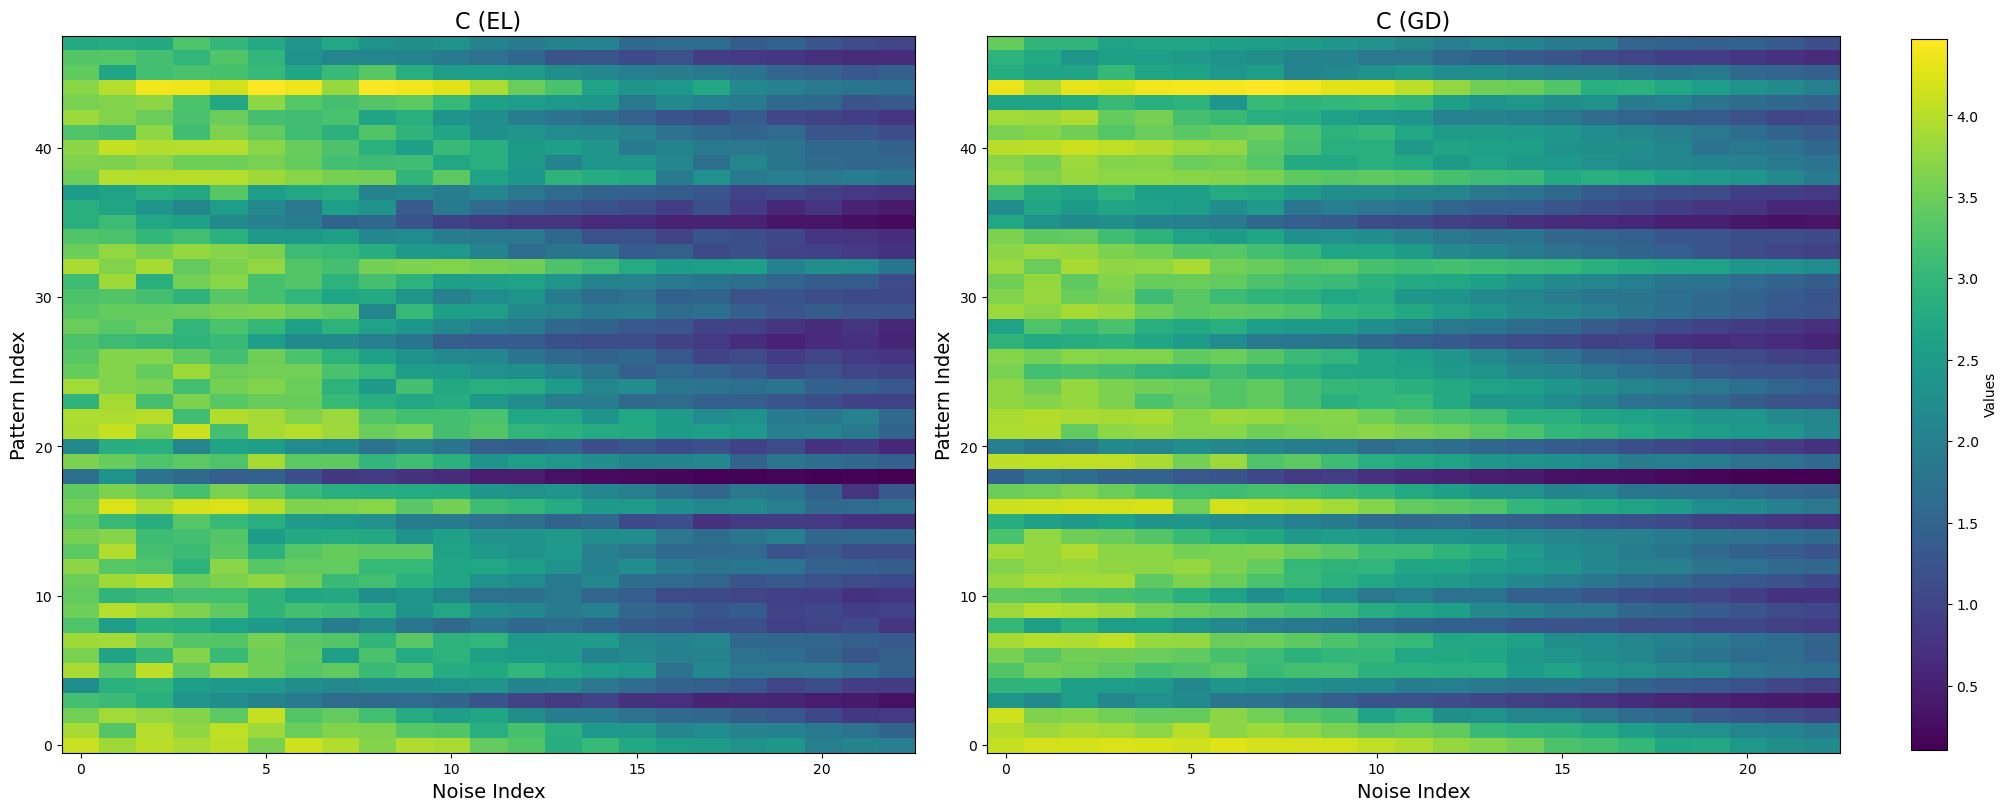

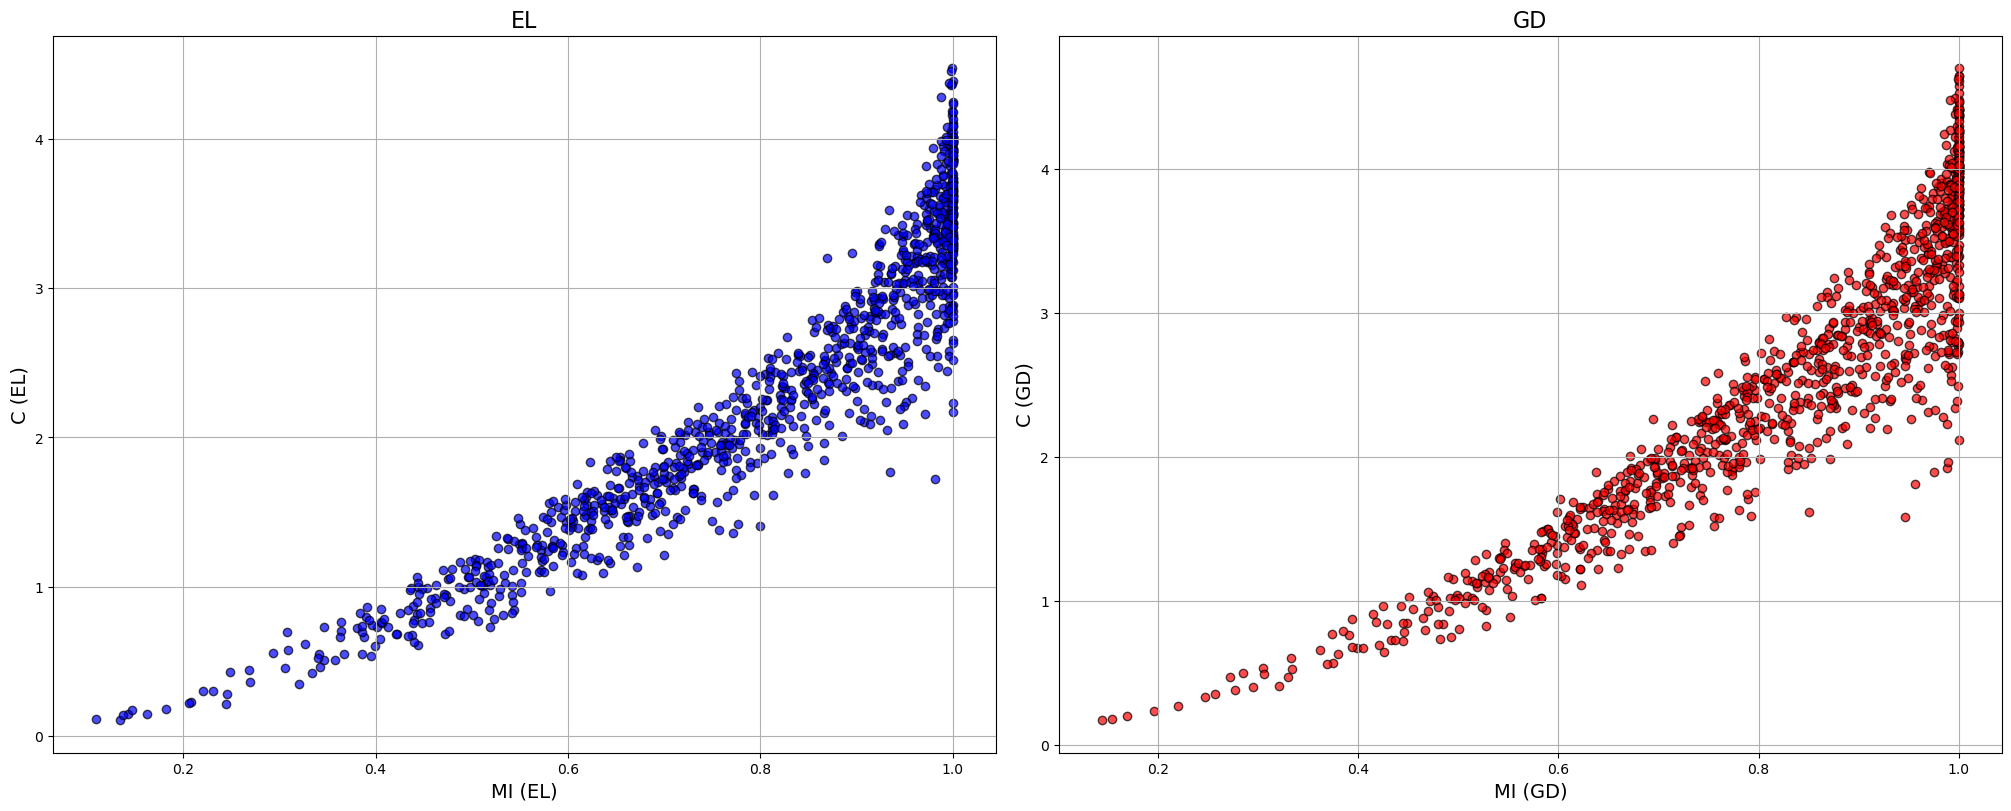

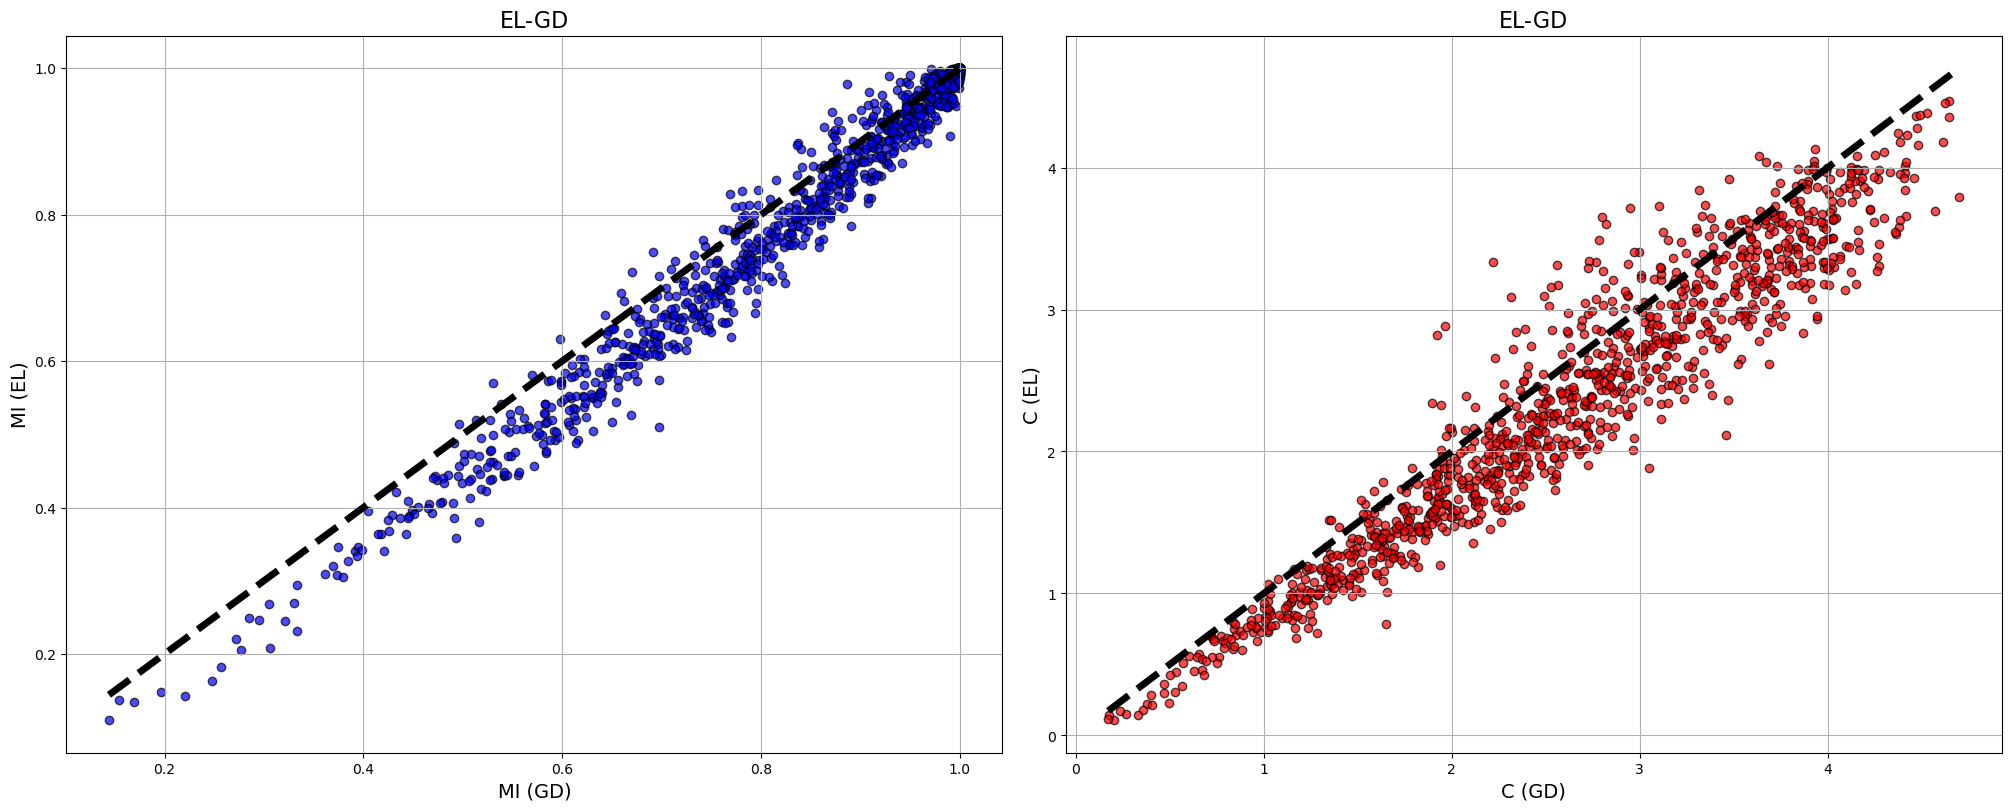

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Plot align_I_EL
im1 = axes[0].imshow(align_I_EL, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('MI (EL)', fontsize=16)
axes[0].set_xlabel('Noise Index', fontsize=14)
axes[0].set_ylabel('Pattern Index', fontsize=14)

# Plot align_I_GD
im2 = axes[1].imshow(align_I_GD, aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('MI (GD)', fontsize=16)
axes[1].set_xlabel('Noise Index', fontsize=14)
axes[1].set_ylabel('Pattern Index', fontsize=14)

# Add a common colorbar
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Values')

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Plot align_I_EL
im1 = axes[0].imshow(align_D_EL, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('C (EL)', fontsize=16)
axes[0].set_xlabel('Noise Index', fontsize=14)
axes[0].set_ylabel('Pattern Index', fontsize=14)

# Plot align_I_GD
im2 = axes[1].imshow(align_D_GD, aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('C (GD)', fontsize=16)
axes[1].set_xlabel('Noise Index', fontsize=14)
axes[1].set_ylabel('Pattern Index', fontsize=14)

# Add a common colorbar
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Values')

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Scatter plot for EL
axes[0].scatter(align_I_EL.flatten(), align_D_EL.flatten(), alpha=0.7, c='blue', edgecolors='k')
axes[0].set_xlabel('MI (EL)', fontsize=14)
axes[0].set_ylabel('C (EL)', fontsize=14)
axes[0].set_title('EL', fontsize=16)
axes[0].grid(True)

# Scatter plot for GD
axes[1].scatter(align_I_GD.flatten(), align_D_GD.flatten(), alpha=0.7, c='red', edgecolors='k')
axes[1].set_xlabel('MI (GD)', fontsize=14)
axes[1].set_ylabel('C (GD)', fontsize=14)
axes[1].set_title('GD', fontsize=16)
axes[1].grid(True)

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Scatter plot for EL vs GD
axes[0].scatter(align_I_GD.flatten(), align_I_EL.flatten(), alpha=0.7, c='blue', edgecolors='k')
axes[0].plot([align_I_GD.min(), align_I_GD.max()], [align_I_GD.min(), align_I_GD.max()], color='black', linestyle='--', linewidth=5)  # Add y=x line
axes[0].set_xlabel('MI (GD)', fontsize=14)
axes[0].set_ylabel('MI (EL)', fontsize=14)
axes[0].set_title('EL-GD', fontsize=16)
axes[0].grid(True)

# Scatter plot for EL vs GD
axes[1].scatter(align_D_GD.flatten(), align_D_EL.flatten(), alpha=0.7, c='red', edgecolors='k')
axes[1].plot([align_D_GD.min(), align_D_GD.max()], [align_D_GD.min(), align_D_GD.max()], color='black', linestyle='--', linewidth=5)  # Add y=x line
axes[1].set_xlabel('C (GD)', fontsize=14)
axes[1].set_ylabel('C (EL)', fontsize=14)
axes[1].set_title('EL-GD', fontsize=16)
axes[1].grid(True)

plt.show()




